# 数据分析岗位招聘需求分析

本项目基于 2253 条 Data Analyst 岗位数据，使用 Python、Pandas 和 Matplotlib 对数据分析岗位的技能需求、地区分布、行业分布、薪资水平和岗位类别进行分析。

项目目标是了解数据分析 / BI 岗位最常见的技能要求，并形成可量化的岗位市场画像。

# 1. 数据读取与基础检查

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

os.makedirs("charts", exist_ok=True)

df = pd.read_csv(r"D:\Data_Analyst_Jobs_Analysis\data\DataAnalyst.csv")

df.shape

(2253, 16)

In [2]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(2),

In [4]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')

In [5]:
skill_keywords = {
    "SQL": "sql",
    "Python": "python",
    "Excel": "excel",
    "Tableau": "tableau",
    "Power BI": "power bi",
    "R": " r ",
    "Statistics": "statistics",
    "Machine Learning": "machine learning",
    "Spark": "spark",
    "AWS": "aws",
    "Communication": "communication"
}

job_desc = df["Job Description"].fillna("").str.lower()

skill_counts = {}

for skill, keyword in skill_keywords.items():
    skill_counts[skill] = job_desc.str.contains(keyword, regex=False).sum()

skill_counts

{'SQL': np.int64(1389),
 'Python': np.int64(637),
 'Excel': np.int64(1354),
 'Tableau': np.int64(620),
 'Power BI': np.int64(180),
 'R': np.int64(121),
 'Statistics': np.int64(563),
 'Machine Learning': np.int64(180),
 'Spark': np.int64(89),
 'AWS': np.int64(275),
 'Communication': np.int64(1154)}

# 2. 数据清洗

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

os.makedirs(r"D:\Data_Analyst_Jobs_Analysis\charts", exist_ok=True)

df = df.drop(columns=["Unnamed: 0"])

df["Company Name"] = (
    df["Company Name"]
    .fillna("Unknown")
    .astype(str)
    .str.split("\n")
    .str[0]
    .str.strip()
)

df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [9]:
df["Job Title"].value_counts().head(20)

Job Title
Data Analyst               405
Senior Data Analyst         90
Junior Data Analyst         30
Business Data Analyst       28
Sr. Data Analyst            21
Data Analyst Junior         17
Data Analyst II             17
Data Quality Analyst        17
Data Governance Analyst     16
Lead Data Analyst           15
Data Reporting Analyst      13
Financial Data Analyst      12
Data Analyst I              11
Data Analyst III            11
Marketing Data Analyst       9
Sr Data Analyst              9
Data Management Analyst      8
Data Warehouse Analyst       8
Data Science Analyst         7
Technical Data Analyst       7
Name: count, dtype: int64

# 3. 技能需求分析

In [10]:

job_desc = df["Job Description"].fillna("").str.lower()

skill_patterns = {
    "SQL": r"\bsql\b",
    "Python": r"\bpython\b",
    "Excel": r"\bexcel\b",
    "Tableau": r"\btableau\b",
    "Power BI": r"\bpower\s*bi\b|\bpowerbi\b",
    "R": r"\br\b",
    "Statistics": r"\bstatistics\b|\bstatistical\b",
    "Machine Learning": r"\bmachine learning\b",
    "Data Visualization": r"\bdata visualization\b|\bvisualization\b",
    "ETL": r"\betl\b",
    "Spark": r"\bspark\b",
    "AWS": r"\baws\b",
    "Communication": r"\bcommunication\b|\bcommunicate\b",
    "Dashboard": r"\bdashboard\b|\bdashboards\b"
}

skill_counts = {}

for skill, pattern in skill_patterns.items():
    skill_counts[skill] = job_desc.str.contains(pattern, regex=True).sum()

skill_series = pd.Series(skill_counts).sort_values(ascending=False)

skill_series

SQL                   1363
Communication         1322
Excel                  903
Statistics             836
Python                 633
Tableau                617
Dashboard              529
R                      441
Data Visualization     421
ETL                    336
Power BI               246
Machine Learning       179
AWS                    132
Spark                   71
dtype: int64

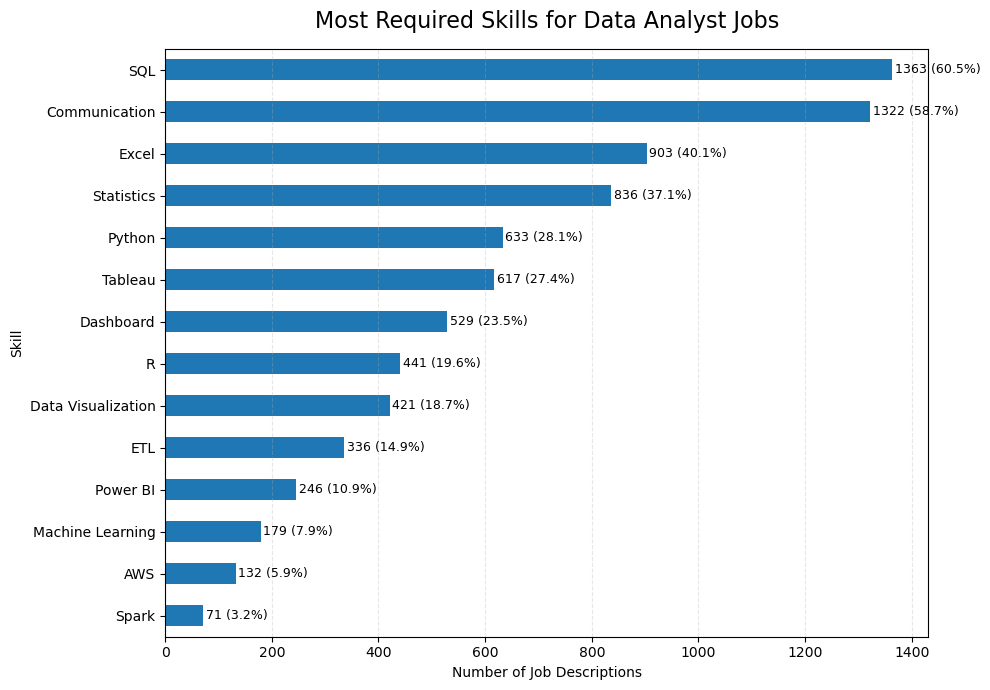

In [11]:
plt.figure(figsize=(10, 7))

ax = skill_series.sort_values().plot(kind="barh")

plt.title(
    "Most Required Skills for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Number of Job Descriptions")
plt.ylabel("Skill")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# 显示数字和百分比
total_jobs = len(df)

for i, v in enumerate(skill_series.sort_values().values):
    percentage = v / total_jobs * 100
    ax.text(
        v + 5,
        i,
        f"{v} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\skill_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 技能需求分析

在 2253 条 Data Analyst 岗位数据中，SQL 是出现频率最高的硬技能，共出现 1363 次，占全部岗位约 60.5%。

其次是 Communication、Excel、Statistics 和 Python，说明数据分析岗位不仅要求数据处理能力，也非常重视业务沟通和结果表达能力。

从岗位能力画像看，SQL、Excel、Python 和统计基础是数据分析/BI 岗位中的高频核心技能。

# 4. 地区分布分析

In [12]:
location_counts = df["Location"].value_counts().head(15)

location_counts

Location
New York, NY         310
Chicago, IL          130
San Francisco, CA    119
Austin, TX            81
Los Angeles, CA       80
Charlotte, NC         78
Houston, TX           72
Dallas, TX            66
San Diego, CA         62
Philadelphia, PA      56
Denver, CO            47
San Antonio, TX       45
San Jose, CA          38
Phoenix, AZ           35
Jersey City, NJ       33
Name: count, dtype: int64

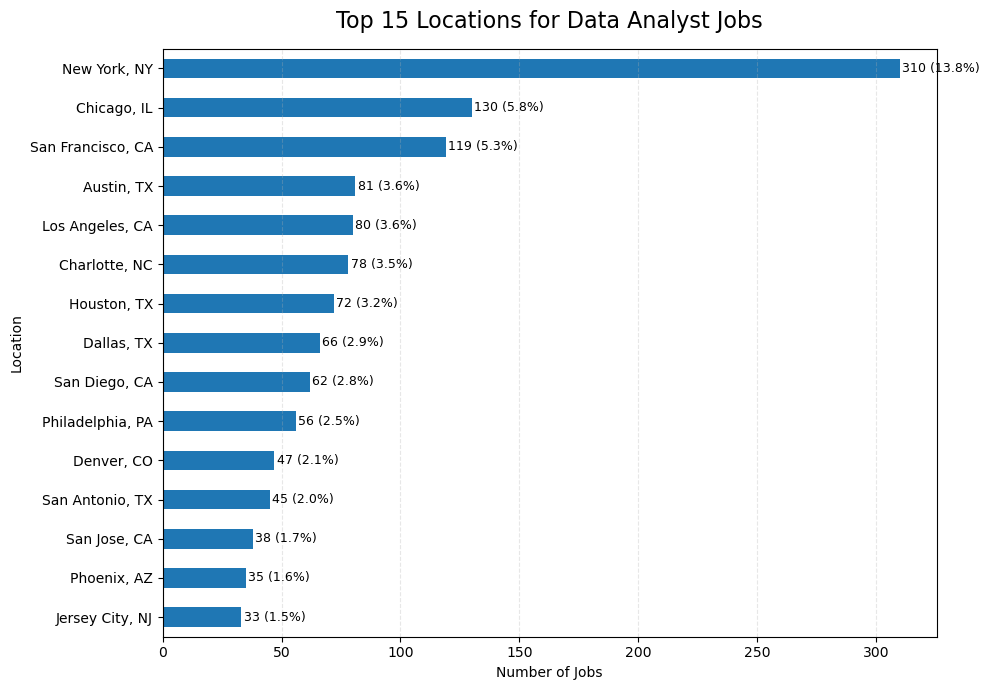

In [13]:
plt.figure(figsize=(10, 7))

ax = location_counts.sort_values().plot(kind="barh")

plt.title(
    "Top 15 Locations for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Number of Jobs")
plt.ylabel("Location")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# 显示数量和百分比
total_jobs = len(df)

for i, v in enumerate(location_counts.sort_values().values):
    percentage = v / total_jobs * 100
    ax.text(
        v + 1,
        i,
        f"{v} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\top_locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 岗位地区分布分析

通过统计 2253 条 Data Analyst 岗位数据发现，岗位分布具有明显的城市集中现象。

其中，New York, NY 的岗位数量最多，共 310 条，占全部岗位约 13.8%。Chicago, IL 和 San Francisco, CA 分别位列第二和第三，岗位数量分别为 130 条和 119 条。

这说明数据分析岗位更集中于金融、科技、商业资源较集中的大城市。城市集中度可以为岗位供给、人才流动和区域机会分析提供参考。

# 5. 行业分布分析

In [14]:
industry_counts = df["Industry"].value_counts().head(15)

industry_counts

Industry
-1                                         353
IT Services                                325
Staffing & Outsourcing                     323
Health Care Services & Hospitals           151
Computer Hardware & Software               111
Consulting                                 111
Investment Banking & Asset Management       78
Enterprise Software & Network Solutions     69
Internet                                    65
Advertising & Marketing                     51
Banks & Credit Unions                       51
Insurance Carriers                          47
Colleges & Universities                     40
Accounting                                  39
Biotech & Pharmaceuticals                   33
Name: count, dtype: int64

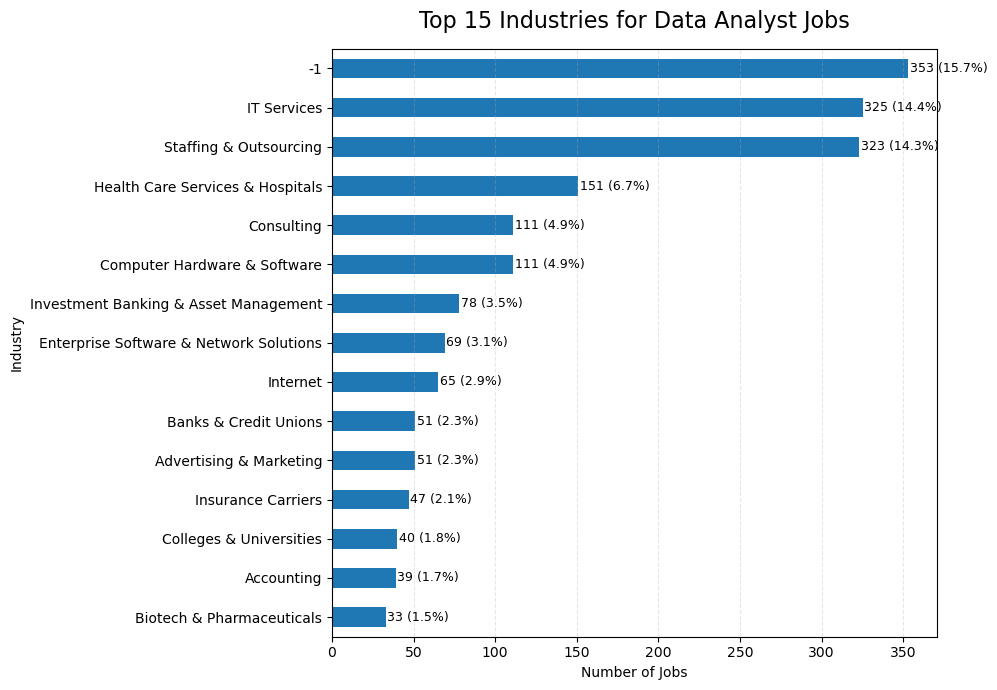

In [15]:
plt.figure(figsize=(10, 7))

ax = industry_counts.sort_values().plot(kind="barh")

plt.title(
    "Top 15 Industries for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Number of Jobs")
plt.ylabel("Industry")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

total_jobs = len(df)

for i, v in enumerate(industry_counts.sort_values().values):
    percentage = v / total_jobs * 100
    ax.text(
        v + 1,
        i,
        f"{v} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\top_industries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# 把 Industry 里的 -1 替换成 Unknown
df["Industry"] = df["Industry"].replace("-1", "Unknown")

In [17]:
industry_counts = (
    df[df["Industry"] != "Unknown"]["Industry"]
    .value_counts()
    .head(15)
)

industry_counts

Industry
IT Services                                325
Staffing & Outsourcing                     323
Health Care Services & Hospitals           151
Computer Hardware & Software               111
Consulting                                 111
Investment Banking & Asset Management       78
Enterprise Software & Network Solutions     69
Internet                                    65
Advertising & Marketing                     51
Banks & Credit Unions                       51
Insurance Carriers                          47
Colleges & Universities                     40
Accounting                                  39
Biotech & Pharmaceuticals                   33
Social Assistance                           23
Name: count, dtype: int64

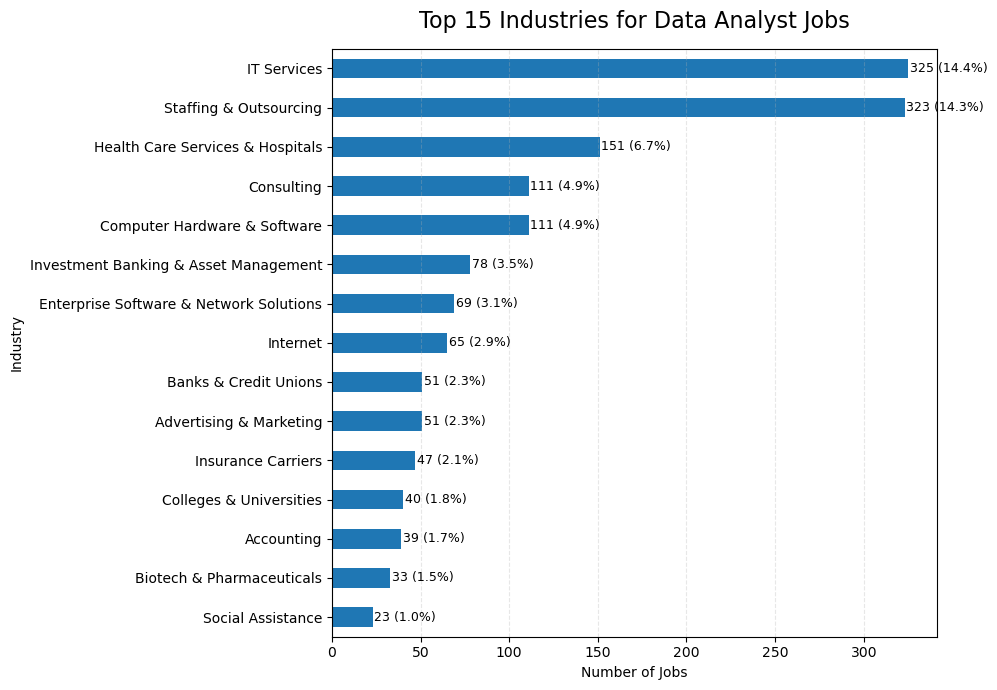

In [18]:
plt.figure(figsize=(10, 7))

ax = industry_counts.sort_values().plot(kind="barh")

plt.title(
    "Top 15 Industries for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Number of Jobs")
plt.ylabel("Industry")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

total_jobs = len(df)

for i, v in enumerate(industry_counts.sort_values().values):
    percentage = v / total_jobs * 100
    ax.text(
        v + 1,
        i,
        f"{v} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\top_industries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 行业分布分析

在清洗 Industry 字段时，发现部分岗位的行业字段为 -1，说明原始数据中存在缺失或未知行业信息。本项目将其统一处理为 Unknown，并在行业分布分析中剔除该类记录。

清洗后结果显示，Data Analyst 岗位主要集中在 IT Services、Staffing & Outsourcing、Health Care Services & Hospitals、Computer Hardware & Software、Consulting 等行业。

这说明数据分析岗位并不只存在于互联网公司，也广泛分布在 IT 服务、医疗、咨询、金融等行业。

# 6. 薪资字段清洗与薪资分析

In [19]:
df["Salary Estimate"].value_counts().head(20)

Salary Estimate
$42K-$76K (Glassdoor est.)     57
$41K-$78K (Glassdoor est.)     57
$50K-$86K (Glassdoor est.)     41
$35K-$67K (Glassdoor est.)     33
$43K-$76K (Glassdoor est.)     31
$58K-$93K (Glassdoor est.)     31
$60K-$124K (Glassdoor est.)    31
$37K-$66K (Glassdoor est.)     30
$37K-$68K (Glassdoor est.)     30
$60K-$66K (Glassdoor est.)     30
$97K-$129K (Glassdoor est.)    30
$46K-$87K (Glassdoor est.)     30
$69K-$127K (Glassdoor est.)    30
$30K-$53K (Glassdoor est.)     30
$43K-$69K (Glassdoor est.)     30
$35K-$42K (Glassdoor est.)     30
$46K-$86K (Glassdoor est.)     30
$42K-$66K (Glassdoor est.)     30
$64K-$113K (Glassdoor est.)    30
$60K-$110K (Glassdoor est.)    30
Name: count, dtype: int64

In [20]:
import numpy as np
import re

def parse_salary(s):
    # 处理空值或异常值
    if pd.isna(s) or s == "-1":
        return np.nan, np.nan, np.nan
    
    # 提取类似 $42K-$76K 里面的数字
    numbers = re.findall(r"\$(\d+)K", s)
    
    if len(numbers) >= 2:
        min_salary = int(numbers[0])
        max_salary = int(numbers[1])
        avg_salary = (min_salary + max_salary) / 2
        return min_salary, max_salary, avg_salary
    else:
        return np.nan, np.nan, np.nan

df[["min_salary_k", "max_salary_k", "avg_salary_k"]] = df["Salary Estimate"].apply(
    lambda x: pd.Series(parse_salary(x))
)

df[["Salary Estimate", "min_salary_k", "max_salary_k", "avg_salary_k"]].head()

,Salary Estimate,min_salary_k,max_salary_k,avg_salary_k
0,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
1,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
2,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
3,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
4,$37K-$66K (Glassdoor est.),37.0,66.0,51.5


In [21]:
df["avg_salary_k"].isnull().sum()

np.int64(1)

In [22]:
df["avg_salary_k"].describe()

count    2252.000000
mean       72.123002
std        23.600734
min        33.500000
25%        58.000000
50%        69.000000
75%        80.500000
max       150.000000
Name: avg_salary_k, dtype: float64

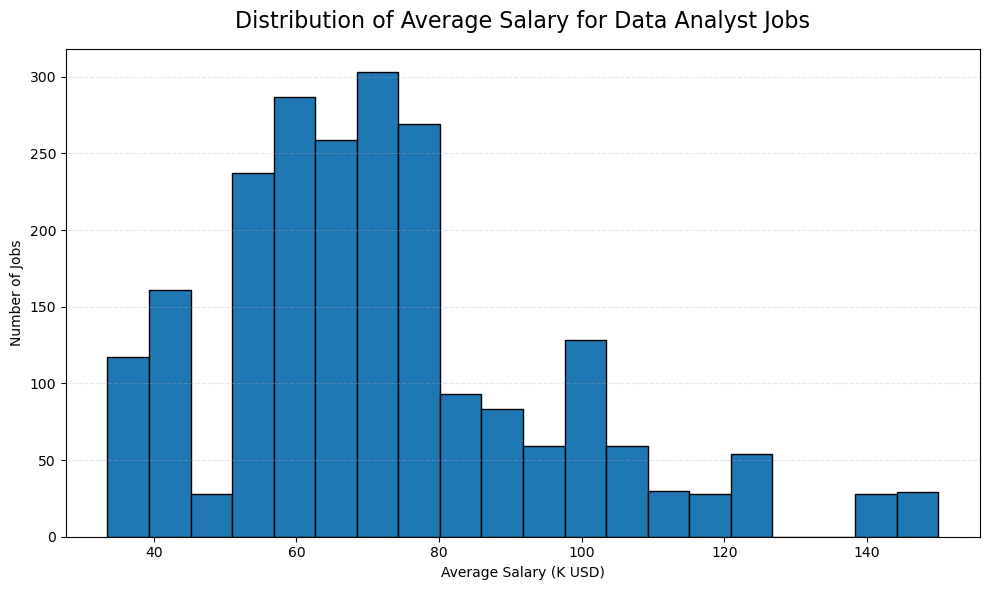

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["avg_salary_k"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title(
    "Distribution of Average Salary for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Average Salary (K USD)")
plt.ylabel("Number of Jobs")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 薪资分布分析

通过对 Salary Estimate 字段进行清洗，将原始的薪资区间转换为最低薪资、最高薪资和平均薪资。

分析结果显示，Data Analyst 岗位平均薪资约为 72.1K 美元/年，中位数为 69K 美元/年。大多数岗位薪资集中在 58K 到 80.5K 美元之间，说明该岗位整体薪资处于较稳定的中等偏上水平。

In [24]:
industry_salary = (
    df[df["Industry"] != "Unknown"]
    .groupby("Industry")["avg_salary_k"]
    .agg(["mean", "count"])
)

# 只保留岗位数不少于 20 的行业，避免样本太少导致误判
industry_salary = industry_salary[industry_salary["count"] >= 20]

industry_salary = industry_salary.sort_values("mean", ascending=False).head(15)

industry_salary

,mean,count
Industry,,
Biotech & Pharmaceuticals,83.106061,33
Internet,79.661538,65
Computer Hardware & Software,77.648649,111
Enterprise Software & Network Solutions,77.326087,69
Accounting,76.294872,39
Staffing & Outsourcing,73.237578,322
Health Care Services & Hospitals,72.807947,151
Advertising & Marketing,72.598039,51
IT Services,71.349231,325


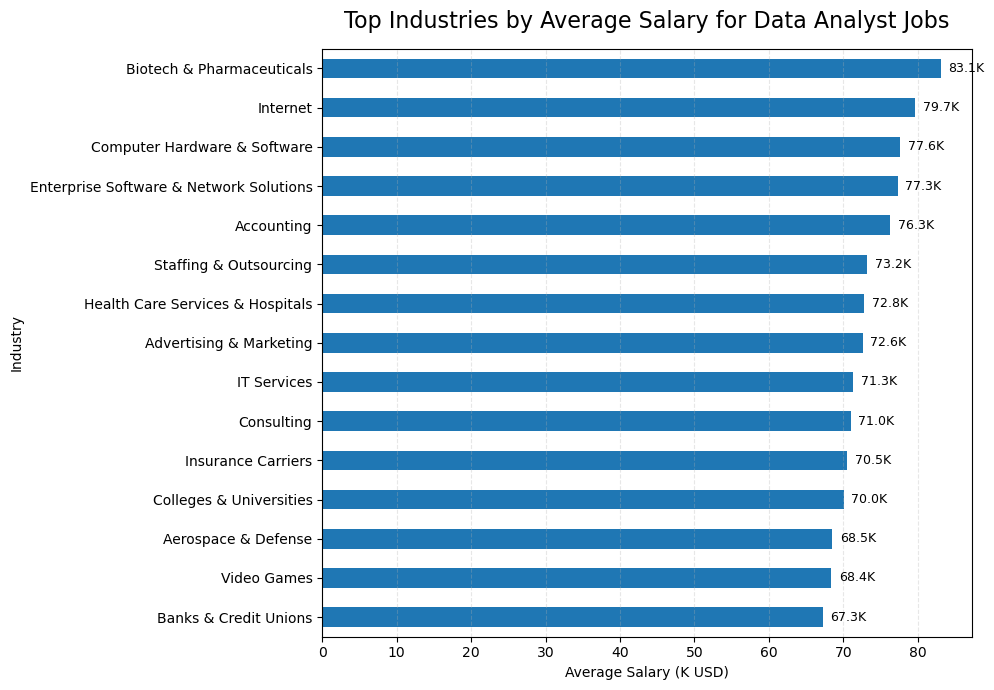

In [25]:
plt.figure(figsize=(10, 7))

ax = industry_salary["mean"].sort_values().plot(kind="barh")

plt.title(
    "Top Industries by Average Salary for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Average Salary (K USD)")
plt.ylabel("Industry")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for i, v in enumerate(industry_salary["mean"].sort_values().values):
    ax.text(
        v + 1,
        i,
        f"{v:.1f}K",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\salary_by_industry.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 行业薪资分析

在岗位数量不少于 20 条的行业中，Biotech & Pharmaceuticals 行业的 Data Analyst 平均薪资最高，约为 83.1K 美元/年。

Internet、Computer Hardware & Software、Enterprise Software & Network Solutions 等技术相关行业的薪资也处于较高水平。

这说明数据分析岗位虽然分布在多个行业，但技术、互联网、生物医药等行业往往提供更高的薪资水平。

# 7. 技能与薪资关系分析

In [26]:

job_desc = df["Job Description"].fillna("").str.lower()

skill_patterns = {
    "SQL": r"\bsql\b",
    "Python": r"\bpython\b",
    "Excel": r"\bexcel\b",
    "Tableau": r"\btableau\b",
    "Power BI": r"\bpower\s*bi\b|\bpowerbi\b",
    "R": r"\br\b",
    "Statistics": r"\bstatistics\b|\bstatistical\b",
    "Machine Learning": r"\bmachine learning\b",
    "Data Visualization": r"\bdata visualization\b|\bvisualization\b",
    "ETL": r"\betl\b",
    "Spark": r"\bspark\b",
    "AWS": r"\baws\b",
    "Communication": r"\bcommunication\b|\bcommunicate\b",
    "Dashboard": r"\bdashboard\b|\bdashboards\b"
}


for skill, pattern in skill_patterns.items():
    df[skill] = job_desc.str.contains(pattern, regex=True)

df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Power BI,R,Statistics,Machine Learning,Data Visualization,ETL,Spark,AWS,Communication,Dashboard
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,...,False,True,True,False,False,False,False,True,False,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,...,False,True,True,False,False,False,False,False,True,True
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,...,False,True,True,False,True,False,False,False,True,True
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,...,True,False,False,False,True,True,False,False,True,False
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,...,False,False,False,False,True,False,False,False,False,False


In [27]:
skill_salary_list = []

for skill in skill_patterns.keys():
    jobs_with_skill = df[df[skill] == True]
    
    skill_salary_list.append({
        "skill": skill,
        "job_count": len(jobs_with_skill),
        "avg_salary_k": jobs_with_skill["avg_salary_k"].mean()
    })

skill_salary = pd.DataFrame(skill_salary_list)

skill_salary = skill_salary.sort_values("avg_salary_k", ascending=False)

skill_salary

,skill,job_count,avg_salary_k
10,Spark,71,75.711268
1,Python,633,74.632701
3,Tableau,617,74.243922
7,Machine Learning,179,74.039106
5,R,441,73.369615
13,Dashboard,529,72.840265
12,Communication,1322,72.421650
6,Statistics,836,72.371411
8,Data Visualization,421,72.205463
0,SQL,1363,71.724302


<Figure size 1000x700 with 0 Axes>

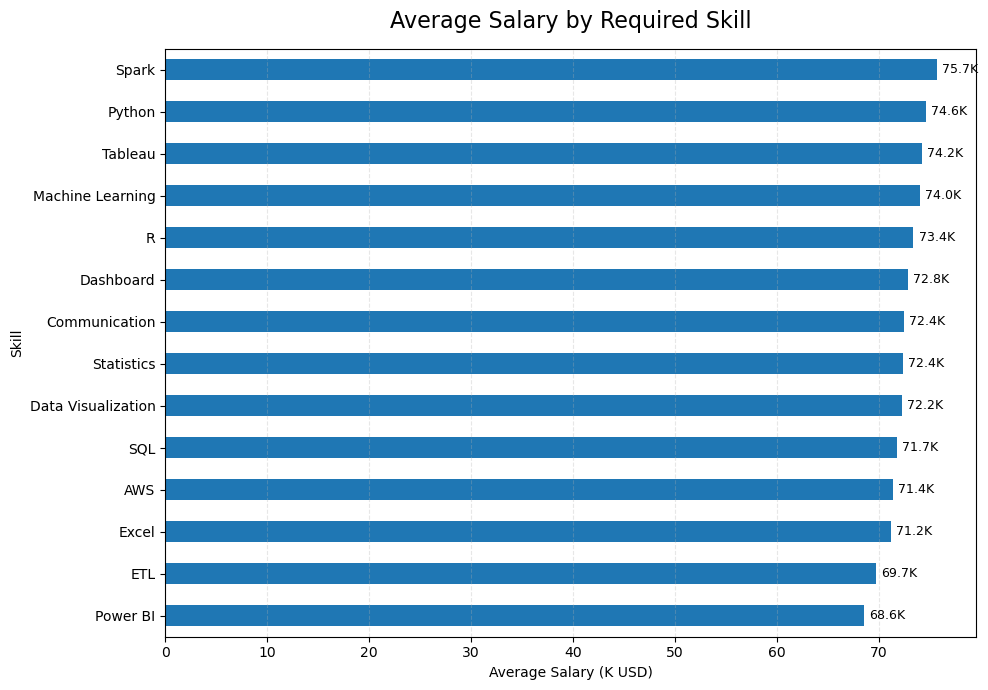

In [28]:
plt.figure(figsize=(10, 7))

ax = skill_salary.sort_values("avg_salary_k").plot(
    kind="barh",
    x="skill",
    y="avg_salary_k",
    legend=False,
    figsize=(10, 7)
)

plt.title(
    "Average Salary by Required Skill",
    fontsize=16,
    pad=15
)

plt.xlabel("Average Salary (K USD)")
plt.ylabel("Skill")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for i, v in enumerate(skill_salary.sort_values("avg_salary_k")["avg_salary_k"].values):
    ax.text(
        v + 0.5,
        i,
        f"{v:.1f}K",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\salary_by_skill.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
overall_avg_salary = df["avg_salary_k"].mean()

skill_salary["salary_premium_k"] = skill_salary["avg_salary_k"] - overall_avg_salary

skill_salary.sort_values("salary_premium_k", ascending=False)

,skill,job_count,avg_salary_k,salary_premium_k
10,Spark,71,75.711268,3.588266
1,Python,633,74.632701,2.509700
3,Tableau,617,74.243922,2.120920
7,Machine Learning,179,74.039106,1.916104
5,R,441,73.369615,1.246613
13,Dashboard,529,72.840265,0.717263
12,Communication,1322,72.421650,0.298648
6,Statistics,836,72.371411,0.248410
8,Data Visualization,421,72.205463,0.082461
0,SQL,1363,71.724302,-0.398699


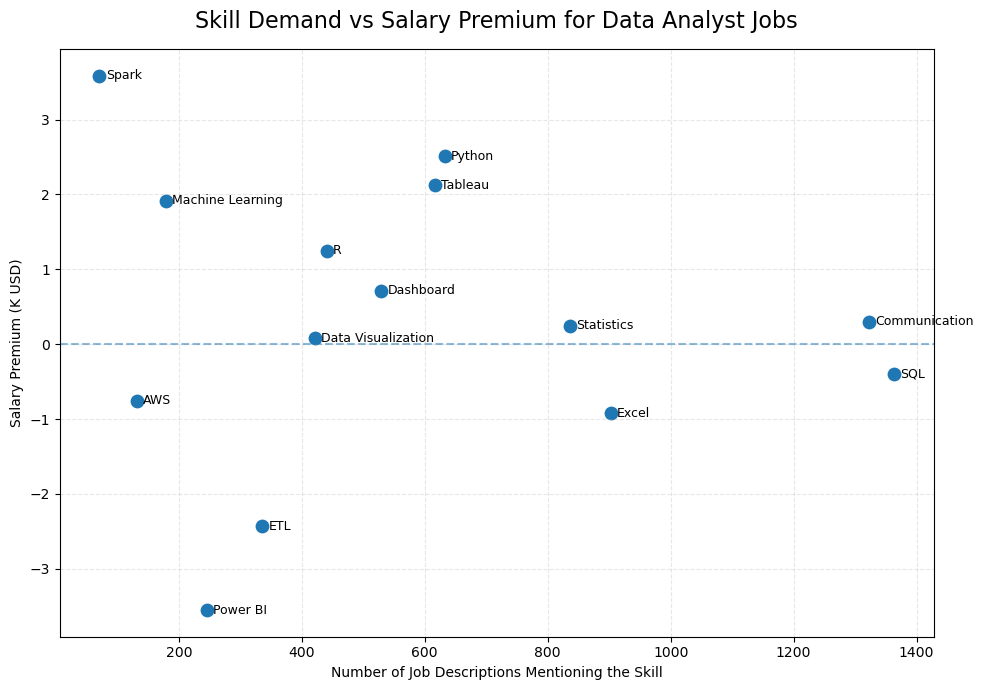

In [30]:
plt.figure(figsize=(10, 7))

plt.scatter(
    skill_salary["job_count"],
    skill_salary["salary_premium_k"],
    s=80
)

# 给每个点加技能名称
for _, row in skill_salary.iterrows():
    plt.text(
        row["job_count"] + 10,
        row["salary_premium_k"],
        row["skill"],
        fontsize=9,
        va="center"
    )

# 画一条0溢价参考线
plt.axhline(
    y=0,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Skill Demand vs Salary Premium for Data Analyst Jobs",
    fontsize=16,
    pad=15
)

plt.xlabel("Number of Job Descriptions Mentioning the Skill")
plt.ylabel("Salary Premium (K USD)")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\skill_value_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 技能价值矩阵分析

本项目进一步比较了不同技能的岗位需求频率与薪资溢价。

结果显示，SQL 是出现频率最高的技能，但薪资溢价并不明显，说明 SQL 更像是数据分析岗位的基础门槛。

Python 和 Tableau 同时具备较高出现频率和正向薪资溢价，是数据分析岗位中更值得优先学习的技能。

Spark 虽然出现次数较少，但对应薪资溢价最高，说明其更偏向高级数据岗位或数据工程岗位，适合作为长期提升方向。

因此，SQL、Excel、Python 和 Tableau 可以视为数据分析/BI 岗位的基础技能组合；Spark、AWS、Machine Learning 等则更偏向进阶能力。

# 8. 岗位类别分析

In [31]:
df["Job Title"].value_counts().head(30)

Job Title
Data Analyst                               405
Senior Data Analyst                         90
Junior Data Analyst                         30
Business Data Analyst                       28
Sr. Data Analyst                            21
Data Analyst Junior                         17
Data Analyst II                             17
Data Quality Analyst                        17
Data Governance Analyst                     16
Lead Data Analyst                           15
Data Reporting Analyst                      13
Financial Data Analyst                      12
Data Analyst I                              11
Data Analyst III                            11
Marketing Data Analyst                       9
Sr Data Analyst                              9
Data Management Analyst                      8
Data Warehouse Analyst                       8
Data Science Analyst                         7
Technical Data Analyst                       7
SQL Data Analyst                             7
Res

In [32]:
def classify_job_title(title):
    title = str(title).lower()
    
    if "senior" in title or "sr" in title or "lead" in title or "principal" in title:
        return "Senior Data Analyst"
    
    elif "business" in title:
        return "Business Data Analyst"
    
    elif "report" in title or "reporting" in title:
        return "Reporting Data Analyst"
    
    elif "health" in title or "healthcare" in title:
        return "Healthcare Data Analyst"
    
    elif "quality" in title:
        return "Data Quality Analyst"
    
    elif "financial" in title or "finance" in title:
        return "Financial Data Analyst"
    
    elif "marketing" in title:
        return "Marketing Data Analyst"
    
    elif "data analyst" in title:
        return "General Data Analyst"
    
    else:
        return "Other Analyst"

df["job_category"] = df["Job Title"].apply(classify_job_title)

df["job_category"].value_counts()

job_category
General Data Analyst       1127
Senior Data Analyst         481
Other Analyst               298
Business Data Analyst       133
Reporting Data Analyst       65
Data Quality Analyst         43
Financial Data Analyst       42
Healthcare Data Analyst      39
Marketing Data Analyst       25
Name: count, dtype: int64

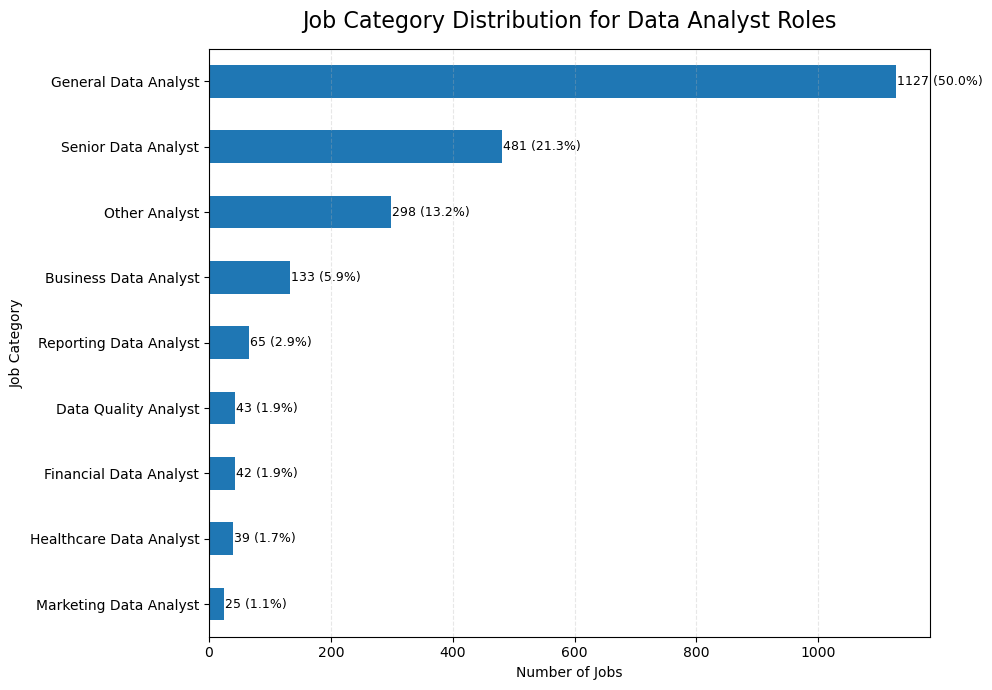

In [34]:
plt.figure(figsize=(10, 7))

ax = job_category_counts.sort_values().plot(kind="barh")

plt.title(
    "Job Category Distribution for Data Analyst Roles",
    fontsize=16,
    pad=15
)

plt.xlabel("Number of Jobs")
plt.ylabel("Job Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

total_jobs = len(df)

for i, v in enumerate(job_category_counts.sort_values().values):
    percentage = v / total_jobs * 100
    ax.text(
        v + 2,
        i,
        f"{v} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\job_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
job_category_salary = (
    df.groupby("job_category")["avg_salary_k"]
    .agg(["mean", "count"])
)

# 只保留样本量不少于20的岗位类别，避免样本太少
job_category_salary = job_category_salary[job_category_salary["count"] >= 20]

job_category_salary = job_category_salary.sort_values("mean", ascending=False)

job_category_salary

,mean,count
job_category,,
Financial Data Analyst,77.357143,42
Marketing Data Analyst,75.820000,25
Senior Data Analyst,74.621622,481
Reporting Data Analyst,72.584615,65
General Data Analyst,71.846051,1127
Other Analyst,70.567340,297
Business Data Analyst,69.695489,133
Data Quality Analyst,67.197674,43
Healthcare Data Analyst,66.089744,39


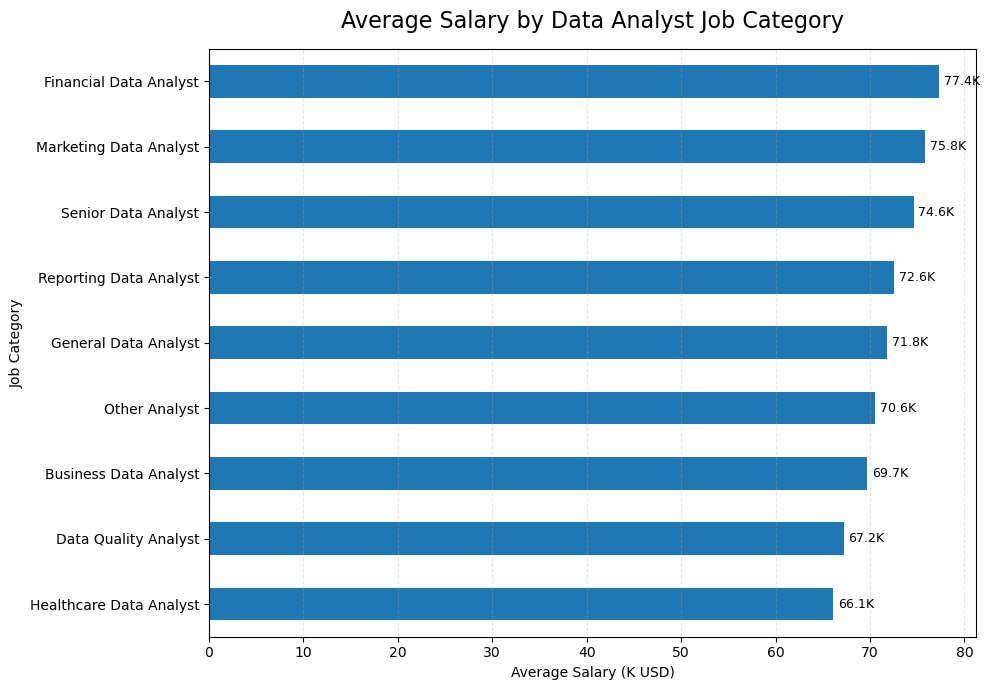

In [36]:
plt.figure(figsize=(10, 7))

ax = job_category_salary["mean"].sort_values().plot(kind="barh")

plt.title(
    "Average Salary by Data Analyst Job Category",
    fontsize=16,
    pad=15
)

plt.xlabel("Average Salary (K USD)")
plt.ylabel("Job Category")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for i, v in enumerate(job_category_salary["mean"].sort_values().values):
    ax.text(
        v + 0.5,
        i,
        f"{v:.1f}K",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    r"D:\Data_Analyst_Jobs_Analysis\charts\salary_by_job_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 岗位类型与薪资分析

本项目根据岗位标题关键词，将 Data Analyst 岗位划分为 General Data Analyst、Senior Data Analyst、Business Data Analyst、Reporting Data Analyst、Financial Data Analyst 等类别。

结果显示，General Data Analyst 是数量最多的岗位类别，共 1127 条，占全部样本接近一半，说明通用数据分析岗是市场中的主要岗位类型。

从薪资角度看，Financial Data Analyst 平均薪资最高，约为 77.36K 美元/年；Marketing Data Analyst 和 Senior Data Analyst 分别位列第二和第三。Senior Data Analyst 不仅岗位数量较多，而且平均薪资明显高于 General Data Analyst，说明经验要求较高的岗位通常具有更高薪资水平。

从岗位层级看，General Data Analyst 和 Reporting Data Analyst 更偏基础分析与报表职责；Senior Data Analyst、Financial Data Analyst 对经验和业务理解要求更高。

（在当前样本中，Financial Data Analyst 平均薪资最高，但由于样本量较小，该结果仅作为参考；Senior Data Analyst 样本量更大，结论稳定性更强。）

# 9. 项目总结

In [37]:
df.to_csv(
    r"D:\Data_Analyst_Jobs_Analysis\data\cleaned_data_analyst_jobs.csv",
    index=False
)

In [38]:
summary = {
    "Total Jobs": len(df),
    "Average Salary (K USD)": round(df["avg_salary_k"].mean(), 2),
    "Median Salary (K USD)": round(df["avg_salary_k"].median(), 2),
    "Top Skill": skill_series.index[0],
    "Top Location": location_counts.index[0],
    "Top Industry": industry_counts.index[0],
    "Most Common Job Category": df["job_category"].value_counts().index[0]
}

summary

{'Total Jobs': 2253,
 'Average Salary (K USD)': np.float64(72.12),
 'Median Salary (K USD)': 69.0,
 'Top Skill': 'SQL',
 'Top Location': 'New York, NY',
 'Top Industry': 'IT Services',
 'Most Common Job Category': 'General Data Analyst'}